In [1]:
%pip install pandas matplotlib seaborn langid scipy torch tensorflow vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print(sys.executable)

c:\Users\milov\Documents\GitHub\Bluesky_Thesis_Milo\venv\Scripts\python.exe


In [3]:
import torch

print(torch.cuda.is_available())    
print(torch.cuda.device_count())   
print(torch.cuda.get_device_name(0))
print(torch.__version__)

True
1
NVIDIA GeForce RTX 4070 Laptop GPU
2.10.0+cu126


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
import roberta_sentiment

vaderAnalyzer = SentimentIntensityAnalyzer()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-0.5482907
-0.50277805


In [5]:
data = '02-25-2026_23-05'

con = sqlite3.connect(f'./data/{data}.db')

old_posts_df = pd.read_sql_query("SELECT * FROM posts", con)
old_reposts_df = pd.read_sql_query("SELECT * FROM reposts", con)

con.close()

In [6]:
con = sqlite3.connect(f'./data/{data}.db')

posts_df = pd.read_sql_query("SELECT * FROM posts WHERE delete_time IS NULL OR delete_time > datetime(post_time, '+24 hours');", con)
reposts_df = pd.read_sql_query("SELECT * FROM reposts WHERE delete_time IS NULL OR delete_time > datetime(repost_time, '+24 hours');", con)

con.close()

In [7]:
print(posts_df)

                                                  post_cid  \
0        bafyreiab3xu4urdxqgvcisd3t3d4ycekiyjxnuo4m37dh...   
1        bafyreih6rgcm6xalqnefkqwqafqxflnvztuamxzc7t5ju...   
2        bafyreigq4qyvjwhspmskgd2k7zwpl4r7ogr32mrrpe2pc...   
3        bafyreifdod5oejn6akmwzp6sqiqlkndczwzemf3hslyt3...   
4        bafyreiczmzu6c7ovanqfsladty3sdcncd35emzgcxp6dh...   
...                                                    ...   
2121519  bafyreicsysziq3mxtxljtsrnrpaav7fm7megeclrn7aze...   
2121520  bafyreiej4hbxmcdlpn3meize4yy2w74iwp4fio5dtubd7...   
2121521  bafyreie72bycxszomj3mfelfgymuwyfrv2lqwvi5l2czw...   
2121522  bafyreigozgzaff3bcdqdz3h4e2cunmwyiu3phxean6oto...   
2121523  bafyreidsb6g4lqurosxmwhho7ln76i3txkb5aqhian6fa...   

                                                  post_uri  \
0        at://did:plc:cmmaulyvqeig6pdwbqhoagec/app.bsky...   
1        at://did:plc:tav3hx2p7heqimob6gqux4ci/app.bsky...   
2        at://did:plc:vapmidvgszje74d6lmhe2nyg/app.bsky...   
3      

In [8]:
m = posts_df.merge(old_posts_df, on='post_cid', how='outer', indicator=True)

In [9]:
m=m[m['_merge'] == 'right_only']

m['delete_interval'] = (pd.to_datetime(m['delete_time_y'], format = 'mixed') - pd.to_datetime(m['post_time_y'], format = 'mixed')).dt.total_seconds() / 3600
print(m['delete_interval'].describe())
#print(m)

count    96854.000000
mean         2.367614
std          4.970598
min         -0.030612
25%          0.014189
50%          0.093251
75%          1.519596
max         23.996970
Name: delete_interval, dtype: float64


In [10]:
# print(posts_df)

posts_df['post_time'] = pd.to_datetime(posts_df['post_time'], format = 'ISO8601')
reposts_df['repost_time'] = pd.to_datetime(reposts_df['repost_time'], format = 'ISO8601')

reposts_merge_df = reposts_df.merge(posts_df[['post_cid', 'post_time']], on = 'post_cid')
invalid_reposts_df = reposts_merge_df[reposts_merge_df['repost_time'] < reposts_merge_df['post_time']]
reposts_merge_df = reposts_merge_df[reposts_merge_df['repost_time'] >= reposts_merge_df['post_time']]

print(f'{len(invalid_reposts_df)} vs {len(reposts_merge_df)}')



426 vs 2626032


In [11]:
repost_groups_df = reposts_merge_df.groupby('post_cid').agg(
    total_reposts=('repost_uri', 'count'),
    first_repost_time=('repost_time', 'min')
).reset_index()

posts_with_reposts_df = pd.merge(posts_df, repost_groups_df, left_on='post_cid', right_on='post_cid', how='inner')

posts_with_reposts_df['time_till_first_repost_min'] = (posts_with_reposts_df['first_repost_time'] - posts_with_reposts_df['post_time']).dt.total_seconds() / 60

news_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 1]
general_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 0]
print(news_posts_df['total_reposts'].describe())
print(news_posts_df['time_till_first_repost_min'].describe())
print(general_posts_df['total_reposts'].describe())
print(general_posts_df['time_till_first_repost_min'].describe())

count    15835.000000
mean        16.566972
std         66.327387
min          1.000000
25%          2.000000
50%          5.000000
75%         13.000000
max       3409.000000
Name: total_reposts, dtype: float64
count    15835.000000
mean        27.682391
std        105.481134
min          0.004783
25%          0.829604
50%          2.491967
75%         10.284483
max       1429.455017
Name: time_till_first_repost_min, dtype: float64
count    246650.000000
mean          9.583191
std          89.846257
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        9015.000000
Name: total_reposts, dtype: float64
count    246650.000000
mean        105.607825
std         239.225868
min           0.000533
25%           1.621304
50%           9.282017
75%          65.163313
max        1439.981250
Name: time_till_first_repost_min, dtype: float64


In [12]:
vader_analyzer = SentimentIntensityAnalyzer()
posts_with_reposts_df['vader_sentiment'] = posts_with_reposts_df['post_text'].apply(lambda x: vader_analyzer.polarity_scores(x)['compound'])

<Figure size 1200x600 with 0 Axes>

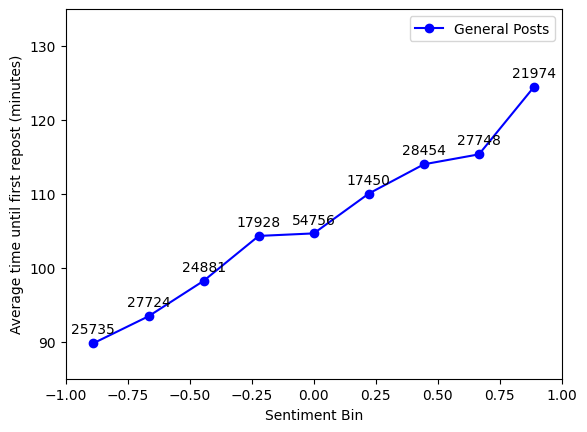

In [13]:
num_bins = 9
posts_with_reposts_df['sentiment_bin'] = pd.cut(posts_with_reposts_df['vader_sentiment'], bins=num_bins)

news_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 1]
general_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 0]

avg_time_to_first_repost_by_sentiment_general = general_posts_df.groupby('sentiment_bin')['time_till_first_repost_min'].mean()
avg_time_to_first_repost_by_sentiment_general = avg_time_to_first_repost_by_sentiment_general.reset_index()
avg_time_to_first_repost_by_sentiment_general['middle'] = avg_time_to_first_repost_by_sentiment_general['sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_sentiment_general['count'] = general_posts_df.groupby('sentiment_bin')['time_till_first_repost_min'].count().values

plt.figure(figsize=(12, 6))

avg_time_to_first_repost_by_sentiment_general.plot(x='middle', y='time_till_first_repost_min',marker='o', color='blue', label='General Posts')  
plt.xlabel('Sentiment Bin')
plt.ylabel('Average time until first repost (minutes)')
plt.xlim(-1, 1)
plt.ylim(85,135)
for x,y,count in zip(avg_time_to_first_repost_by_sentiment_general['middle'], avg_time_to_first_repost_by_sentiment_general['time_till_first_repost_min'], avg_time_to_first_repost_by_sentiment_general['count']):
    plt.annotate(f'{count}', (x, y), textcoords="offset points", xytext=(0,7), ha='center')
plt.show()





In [14]:
print(general_posts_df.count())
print(general_posts_df['total_reposts'].describe(percentiles=[0.8, 0.9, 0.95, 0.99]))
print(general_posts_df['time_till_first_repost_min'].describe())

post_cid                      246650
post_uri                      246650
post_time                     246650
post_text                     246650
delete_time                     1389
likes_count                        0
likes_checked                 246650
check_at                      246650
is_news                       246650
total_reposts                 246650
first_repost_time             246650
time_till_first_repost_min    246650
vader_sentiment               246650
sentiment_bin                 246650
dtype: int64
count    246650.000000
mean          9.583191
std          89.846257
min           1.000000
80%           4.000000
90%          10.000000
95%          22.000000
99%         131.000000
max        9015.000000
Name: total_reposts, dtype: float64
count    246650.000000
mean        105.607825
std         239.225868
min           0.000533
25%           1.621304
50%           9.282017
75%          65.163313
max        1439.981250
Name: time_till_first_repost_min, dtype: f

In [15]:
for sentiment in general_posts_df['sentiment_bin'].unique():
    print(f'Sentiment Bin: {sentiment}')
    print(general_posts_df['sentiment_bin'].value_counts()[sentiment])

Sentiment Bin: (-1.001, -0.777]
25735
Sentiment Bin: (-0.111, 0.111]
54756
Sentiment Bin: (-0.777, -0.555]
27724
Sentiment Bin: (0.333, 0.555]
28454
Sentiment Bin: (0.111, 0.333]
17450
Sentiment Bin: (0.555, 0.777]
27748
Sentiment Bin: (-0.555, -0.333]
24881
Sentiment Bin: (-0.333, -0.111]
17928
Sentiment Bin: (0.777, 1.0]
21974


<Figure size 1200x600 with 0 Axes>

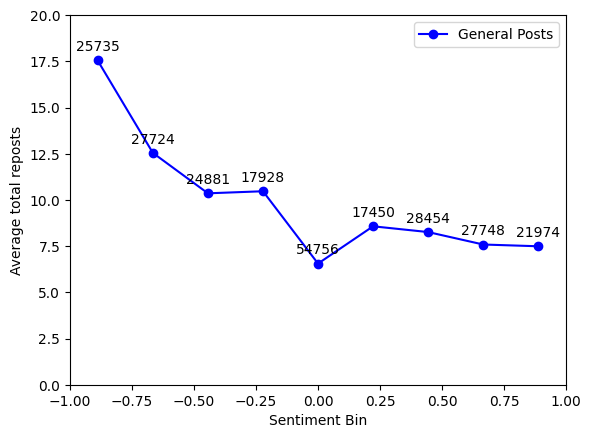

In [16]:
avg_time_to_first_repost_by_sentiment_general = general_posts_df.groupby('sentiment_bin')['total_reposts'].mean()
avg_time_to_first_repost_by_sentiment_general = avg_time_to_first_repost_by_sentiment_general.reset_index()
avg_time_to_first_repost_by_sentiment_general['middle'] = avg_time_to_first_repost_by_sentiment_general['sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_sentiment_general['count'] = general_posts_df.groupby('sentiment_bin')['total_reposts'].count().values

plt.figure(figsize=(12, 6))

avg_time_to_first_repost_by_sentiment_general.plot(x='middle', y='total_reposts',marker='o', color='blue', label='General Posts')  
plt.xlabel('Sentiment Bin')
plt.ylabel('Average total reposts')
plt.xlim(-1, 1)
plt.ylim(0,20)
for x,y,count in zip(avg_time_to_first_repost_by_sentiment_general['middle'], avg_time_to_first_repost_by_sentiment_general['total_reposts'], avg_time_to_first_repost_by_sentiment_general['count']):
    plt.annotate(f'{count}', (x, y), textcoords="offset points", xytext=(0,7), ha='center')
plt.show()

In [17]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [18]:
posts_with_reposts_df["roberta_text"] = (
    posts_with_reposts_df["post_text"]
    .fillna("")
    .astype(str)
    .str.slice(0, 512)
)

#manifesting that McDonald's, Spotify, Roblox, and Twitter all have very awful things happen to them 🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏🙏


from transformers import pipeline

pipe = pipeline("text-classification",
                 model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                 top_k=None,
                 device = device,
                 batch_size=256,
                 torch_dtype=torch.float16)

pipe_cpu = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1,
    top_k=None
)

def safe_pipe(texts):
    try:
        return pipe(texts, batch_size=256)
    except Exception:
        # GPU failed — fallback to CPU for this batch
        print(f"GPU batch failed. Retrying {len(texts)} texts on CPU...")
        try:
            return pipe_cpu(texts, batch_size=32)
        except Exception:
            # If CPU fails, isolate bad text
            if len(texts) == 1:
                print("Skipping problematic text:", texts[0][:120])
                return [None]
            mid = len(texts) // 2
            return safe_pipe(texts[:mid]) + safe_pipe(texts[mid:])

chunk_size = 10000
sentiment_results = []

for i in range(0, len(posts_with_reposts_df), chunk_size):
    print(f"Processing chunk {i} to {min(i+chunk_size, len(posts_with_reposts_df))}...")
    texts = posts_with_reposts_df['roberta_text'].iloc[i:i+chunk_size].tolist()
    sentiments = safe_pipe(texts)
    
    for sentiment in sentiments:
        if sentiment is None:
            sentiment_results.append(None)
            continue
        polarity = 0
        for label_score in sentiment:
            if label_score['label'] == 'positive':
                polarity += label_score['score']
            elif label_score['label'] == 'negative':
                polarity -= label_score['score']
        sentiment_results.append(polarity)

posts_with_reposts_df['roberta_sentiment'] = sentiment_results

#posts_with_reposts_df['roberta_sentiment'] = sentiment_results
print(sentiment_results[:10])

#roberta_sentiments = pipe(posts_with_reposts_df['post_text'].head(1000).tolist())

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing chunk 0 to 10000...
Processing chunk 10000 to 20000...
Processing chunk 20000 to 30000...
Processing chunk 30000 to 40000...
Processing chunk 40000 to 50000...
Processing chunk 50000 to 60000...
Processing chunk 60000 to 70000...
Processing chunk 70000 to 80000...
Processing chunk 80000 to 90000...
Processing chunk 90000 to 100000...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processing chunk 100000 to 110000...
Processing chunk 110000 to 120000...
Processing chunk 120000 to 130000...
Processing chunk 130000 to 140000...
Processing chunk 140000 to 150000...
Processing chunk 150000 to 160000...
Processing chunk 160000 to 170000...
Processing chunk 170000 to 180000...
Processing chunk 180000 to 190000...
Processing chunk 190000 to 200000...
Processing chunk 200000 to 210000...
Processing chunk 210000 to 220000...
Processing chunk 220000 to 230000...
Processing chunk 230000 to 240000...
Processing chunk 240000 to 250000...
Processing chunk 250000 to 260000...
Processing chunk 260000 to 262485...
[-0.1793157458305359, 0.027975070290267467, 0.00892549753189087, 0.1828034771606326, 0.28481289744377136, -0.5698699001222849, -0.9026185548864305, -0.7701198272407055, -0.6874459208920598, 0.03194385580718517]


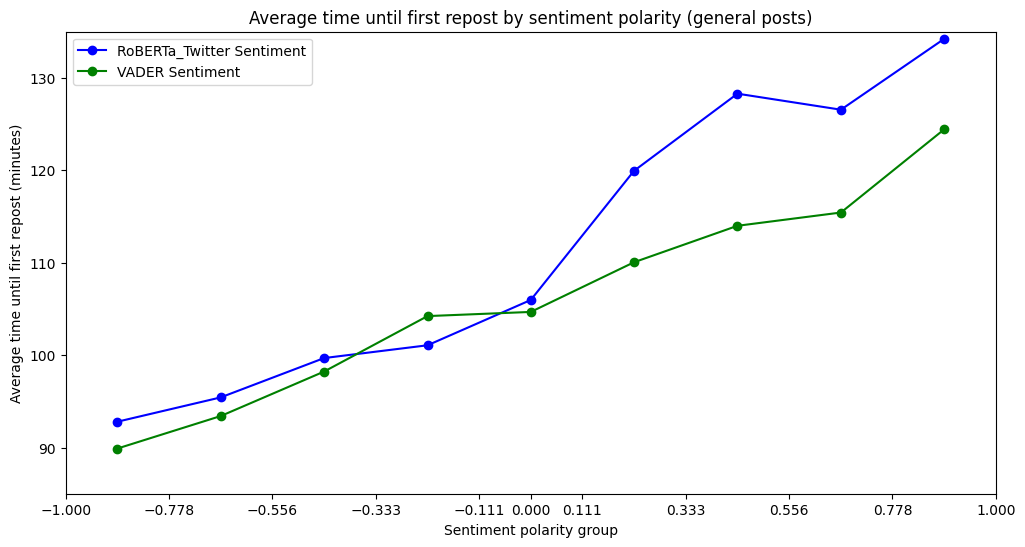

In [19]:
import numpy as np

num_bins = 9
bins = np.linspace(-1, 1, num_bins + 1)
posts_with_reposts_df['rob_sentiment_bin'] = pd.cut(posts_with_reposts_df['roberta_sentiment'], bins=bins)
posts_with_reposts_df['vad_sentiment_bin'] = pd.cut(posts_with_reposts_df['vader_sentiment'], bins=bins)

news_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 1]
general_posts_df = posts_with_reposts_df[posts_with_reposts_df['is_news'] == 0]

avg_time_to_first_repost_by_roberta_sentiment_general = general_posts_df.groupby('rob_sentiment_bin')['time_till_first_repost_min'].mean()
avg_time_to_first_repost_by_roberta_sentiment_general = avg_time_to_first_repost_by_roberta_sentiment_general.reset_index()
avg_time_to_first_repost_by_roberta_sentiment_general['middle'] = avg_time_to_first_repost_by_roberta_sentiment_general['rob_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_roberta_sentiment_general['count'] = general_posts_df.groupby('rob_sentiment_bin')['time_till_first_repost_min'].count().values

avg_time_to_first_repost_by_vader_sentiment_general = general_posts_df.groupby('vad_sentiment_bin')['time_till_first_repost_min'].mean()
avg_time_to_first_repost_by_vader_sentiment_general = avg_time_to_first_repost_by_vader_sentiment_general.reset_index()
avg_time_to_first_repost_by_vader_sentiment_general['middle'] = avg_time_to_first_repost_by_vader_sentiment_general['vad_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_vader_sentiment_general['count'] = general_posts_df.groupby('vad_sentiment_bin')['time_till_first_repost_min'].count().values

fig, ax = plt.subplots(figsize=(12, 6))

avg_time_to_first_repost_by_roberta_sentiment_general.plot(
    x='middle',
    y='time_till_first_repost_min',
    marker='o',
    color='blue',
    label='RoBERTa_Twitter Sentiment',
    ax=ax
)

avg_time_to_first_repost_by_vader_sentiment_general.plot(
    x='middle',
    y='time_till_first_repost_min',
    marker='o',
    color='green',
    label='VADER Sentiment',
    ax=ax
)

ax.set_ylabel('Average time until first repost (minutes)')
ax.set_ylim(85,135)

ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Average time until first repost by sentiment polarity (general posts)')

plt.show()




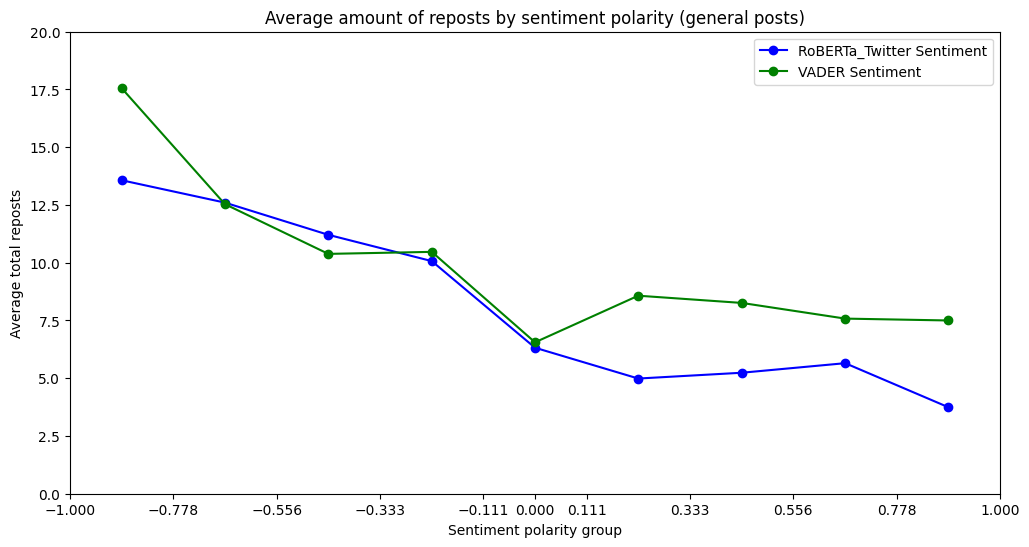

In [20]:
avg_total_reposts_by_roberta_sentiment_general = general_posts_df.groupby('rob_sentiment_bin')['total_reposts'].mean()
avg_total_reposts_by_roberta_sentiment_general = avg_total_reposts_by_roberta_sentiment_general.reset_index()
avg_total_reposts_by_roberta_sentiment_general['middle'] = avg_total_reposts_by_roberta_sentiment_general['rob_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_total_reposts_by_roberta_sentiment_general['count'] = general_posts_df.groupby('rob_sentiment_bin')['total_reposts'].count().values

avg_total_reposts_by_vader_sentiment_general = general_posts_df.groupby('vad_sentiment_bin')['total_reposts'].mean()
avg_total_reposts_by_vader_sentiment_general = avg_total_reposts_by_vader_sentiment_general.reset_index()
avg_total_reposts_by_vader_sentiment_general['middle'] = avg_total_reposts_by_vader_sentiment_general['vad_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_total_reposts_by_vader_sentiment_general['count'] = general_posts_df.groupby('vad_sentiment_bin')['total_reposts'].count().values

fig, ax = plt.subplots(figsize=(12, 6))

avg_total_reposts_by_roberta_sentiment_general.plot(
    x='middle',
    y='total_reposts',
    marker='o',
    color='blue',
    label='RoBERTa_Twitter Sentiment',
    ax=ax
)

avg_total_reposts_by_vader_sentiment_general.plot(
    x='middle',
    y='total_reposts',
    marker='o',
    color='green',
    label='VADER Sentiment',
    ax=ax
)

ax.set_ylabel('Average total reposts')
ax.set_ylim(0,20)

ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Average amount of reposts by sentiment polarity (general posts)')

plt.show()


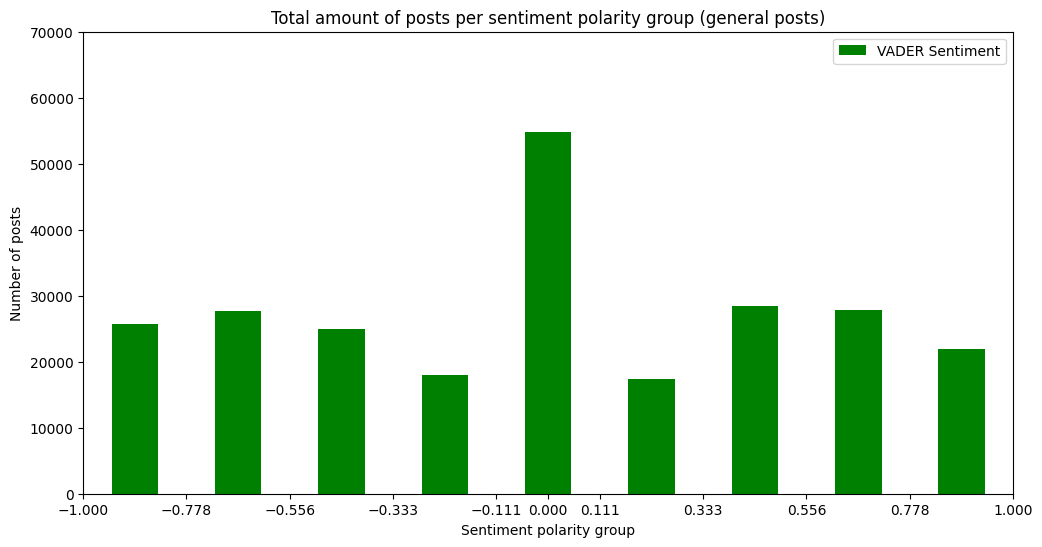

In [21]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    avg_total_reposts_by_vader_sentiment_general['middle'],
    avg_total_reposts_by_vader_sentiment_general['count'],
    width=0.1,
    color='green',
    label='VADER Sentiment',
)

ax.set_ylabel('Number of posts')
ax.set_ylim(0,70000)
ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.legend()
plt.title('Total amount of posts per sentiment polarity group (general posts)')

plt.show()

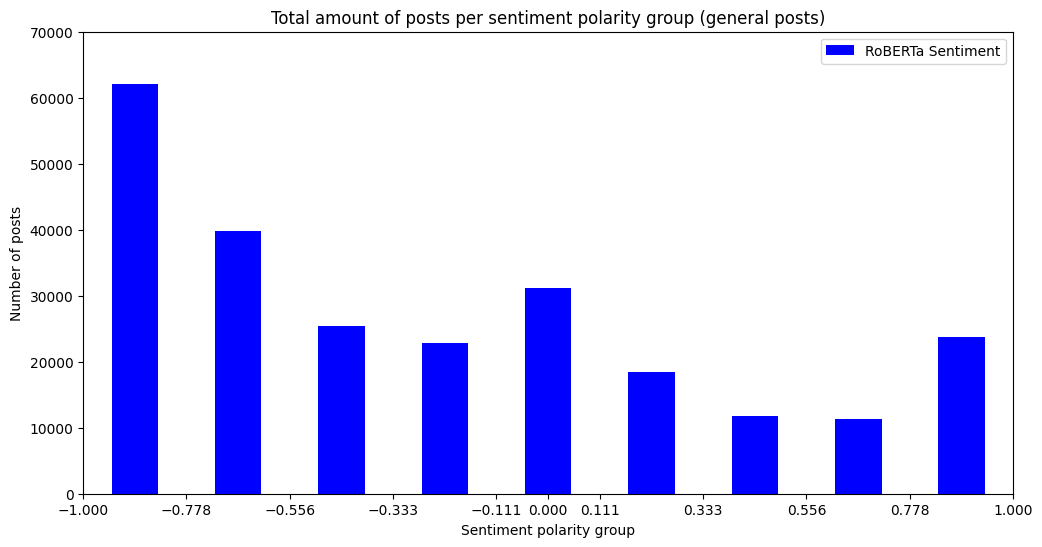

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    avg_total_reposts_by_roberta_sentiment_general['middle'],
    avg_total_reposts_by_roberta_sentiment_general['count'],
    width=0.1,
    color='blue',
    label='RoBERTa Sentiment',
)

ax.set_ylabel('Number of posts')
ax.set_ylim(0,70000)
ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.legend()
plt.title('Total amount of posts per sentiment polarity group (general posts)')


plt.show()




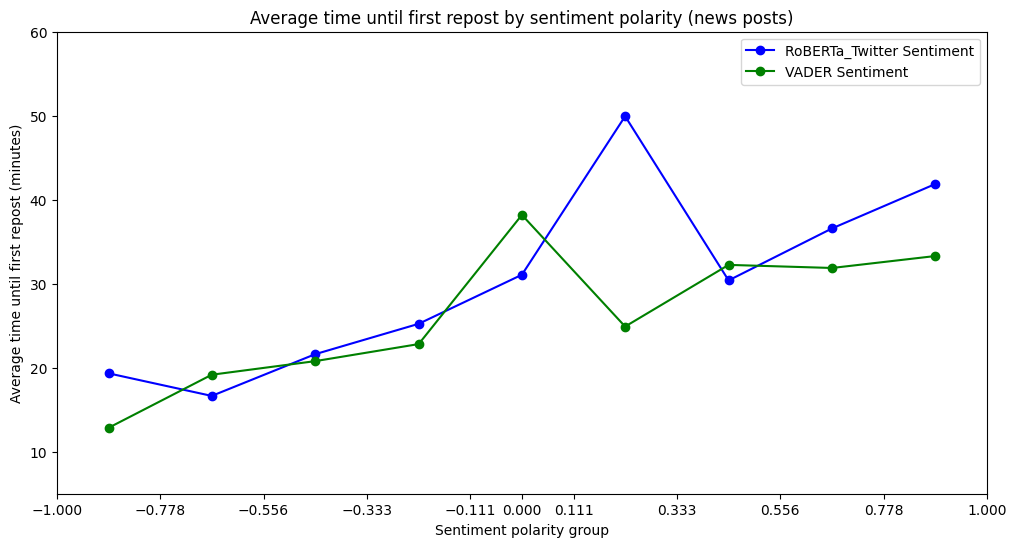

In [23]:
avg_time_to_first_repost_by_roberta_sentiment_news = news_posts_df.groupby('rob_sentiment_bin')['time_till_first_repost_min'].mean()
avg_time_to_first_repost_by_roberta_sentiment_news = avg_time_to_first_repost_by_roberta_sentiment_news.reset_index()
avg_time_to_first_repost_by_roberta_sentiment_news['middle'] = avg_time_to_first_repost_by_roberta_sentiment_news['rob_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_roberta_sentiment_news['count'] = news_posts_df.groupby('rob_sentiment_bin')['time_till_first_repost_min'].count().values

avg_time_to_first_repost_by_vader_sentiment_news = news_posts_df.groupby('vad_sentiment_bin')['time_till_first_repost_min'].mean()
avg_time_to_first_repost_by_vader_sentiment_news = avg_time_to_first_repost_by_vader_sentiment_news.reset_index()
avg_time_to_first_repost_by_vader_sentiment_news['middle'] = avg_time_to_first_repost_by_vader_sentiment_news['vad_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_time_to_first_repost_by_vader_sentiment_news['count'] = news_posts_df.groupby('vad_sentiment_bin')['time_till_first_repost_min'].count().values

fig, ax = plt.subplots(figsize=(12, 6))

avg_time_to_first_repost_by_roberta_sentiment_news.plot(
    x='middle',
    y='time_till_first_repost_min',
    marker='o',
    color='blue',
    label='RoBERTa_Twitter Sentiment',
    ax=ax
)

avg_time_to_first_repost_by_vader_sentiment_news.plot(
    x='middle',
    y='time_till_first_repost_min',
    marker='o',
    color='green',
    label='VADER Sentiment',
    ax=ax
)

ax.set_ylabel('Average time until first repost (minutes)')
ax.set_ylim(5,60)

ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Average time until first repost by sentiment polarity (news posts)')

plt.show()


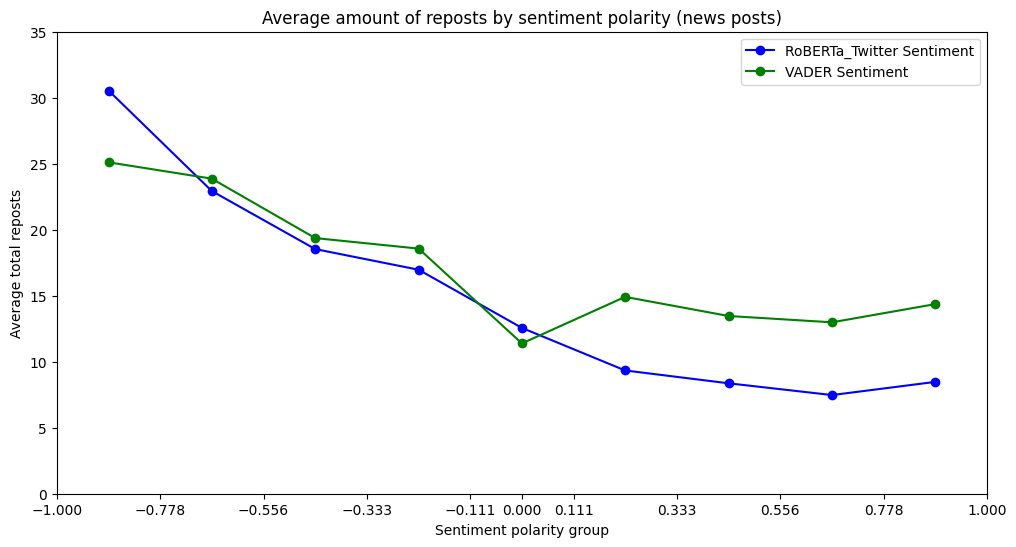

In [24]:
avg_total_reposts_by_roberta_sentiment_news = news_posts_df.groupby('rob_sentiment_bin')['total_reposts'].mean()
avg_total_reposts_by_roberta_sentiment_news = avg_total_reposts_by_roberta_sentiment_news.reset_index()
avg_total_reposts_by_roberta_sentiment_news['middle'] = avg_total_reposts_by_roberta_sentiment_news['rob_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_total_reposts_by_roberta_sentiment_news['count'] = news_posts_df.groupby('rob_sentiment_bin')['total_reposts'].count().values

avg_total_reposts_by_vader_sentiment_news = news_posts_df.groupby('vad_sentiment_bin')['total_reposts'].mean()
avg_total_reposts_by_vader_sentiment_news = avg_total_reposts_by_vader_sentiment_news.reset_index()
avg_total_reposts_by_vader_sentiment_news['middle'] = avg_total_reposts_by_vader_sentiment_news['vad_sentiment_bin'].apply(lambda x: x.mid).astype(float)
avg_total_reposts_by_vader_sentiment_news['count'] = news_posts_df.groupby('vad_sentiment_bin')['total_reposts'].count().values

fig, ax = plt.subplots(figsize=(12, 6))

avg_total_reposts_by_roberta_sentiment_news.plot(
    x='middle',
    y='total_reposts',
    marker='o',
    color='blue',
    label='RoBERTa_Twitter Sentiment',
    ax=ax
)

avg_total_reposts_by_vader_sentiment_news.plot(
    x='middle',
    y='total_reposts',
    marker='o',
    color='green',
    label='VADER Sentiment',
    ax=ax
)

ax.set_ylabel('Average total reposts')
ax.set_ylim(0,35)

ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Average amount of reposts by sentiment polarity (news posts)')

plt.show()

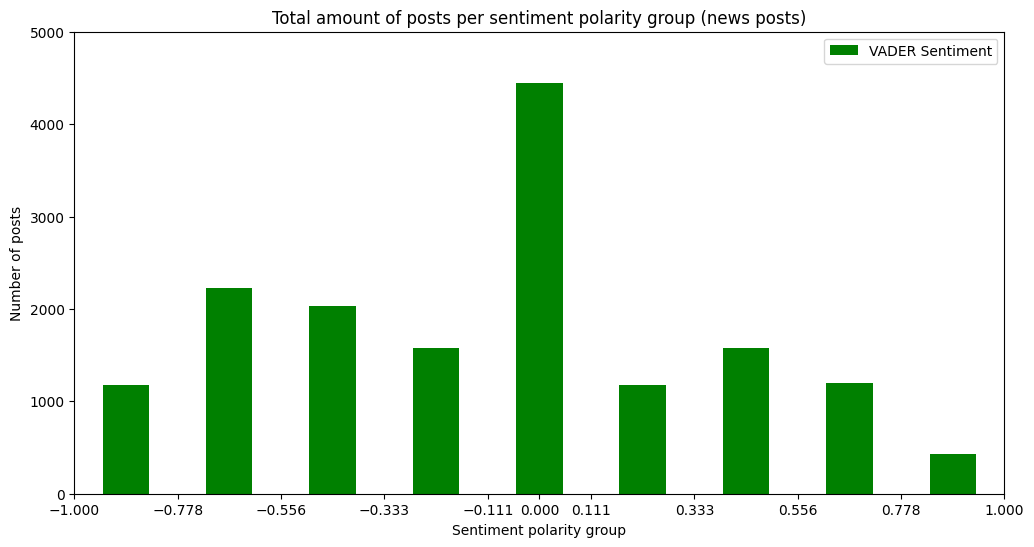

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    avg_total_reposts_by_vader_sentiment_news['middle'],
    avg_total_reposts_by_vader_sentiment_news['count'],
    width=0.1,
    color='green',
    label='VADER Sentiment',
)

ax.set_ylabel('Number of posts')
ax.set_ylim(0,5000)
ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Total amount of posts per sentiment polarity group (news posts)')
plt.legend()

plt.show()

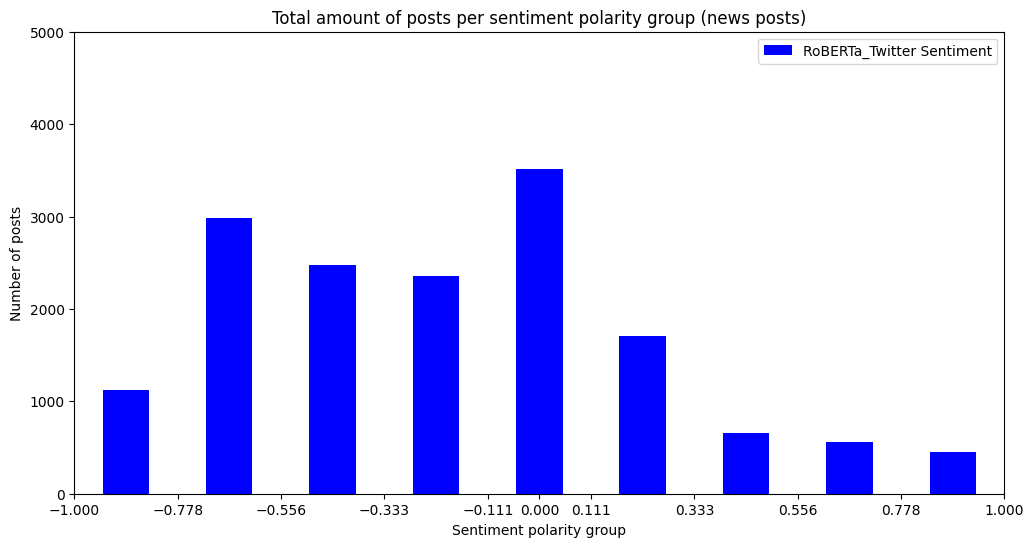

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    avg_total_reposts_by_roberta_sentiment_news['middle'],
    avg_total_reposts_by_roberta_sentiment_news['count'],
    width=0.1,
    color='blue',
    label='RoBERTa_Twitter Sentiment',
)

ax.set_ylabel('Number of posts')
ax.set_ylim(0,5000)
ax.set_xlabel('Sentiment polarity group')
ax.set_xlim(-1, 1)
ax.set_xticks(bins.tolist() + [0])

plt.title('Total amount of posts per sentiment polarity group (news posts)')
plt.legend()

plt.show()

In [27]:
all_news_posts = posts_df[posts_df['is_news'] == 1]


print(f'Unreposted news posts: {len(news_posts_df)} {len(all_news_posts) - len(news_posts_df)} out of {len(all_news_posts)}')
print(news_posts_df['total_reposts'].describe([0.95,0.99,0.999,0.9999]))
print(news_posts_df['total_reposts'].mean() * len(news_posts_df))

Unreposted news posts: 15835 4511 out of 20346
count     15835.000000
mean         16.566972
std          66.327387
min           1.000000
95%          57.000000
99%         165.660000
99.9%       913.806000
99.99%     2286.952800
max        3409.000000
Name: total_reposts, dtype: float64
262338.0


In [28]:
news_posts_df['difference'] = abs(news_posts_df['roberta_sentiment'] - news_posts_df['vader_sentiment'])
display(news_posts_df[news_posts_df['difference'] > 1.5][['post_text', 'roberta_sentiment', 'vader_sentiment', 'difference']].head(20))

,post_text,roberta_sentiment,vader_sentiment,difference
3292,Some election officials believe voters should ...,-0.563099,0.9403,1.503399
6603,Were it not for the steam billowing like mist ...,-0.712798,0.7906,1.503398
7320,"With his words and deeds, U.S. President Donal...",-0.699248,0.8225,1.521748
24007,OTTAWA – The federal government is announcing ...,0.853243,-0.6597,1.512943
31932,The companies behind artificial intelligence l...,-0.771711,0.9081,1.679811
56917,"The 1970s are back, baby, and in a big way! Ce...",0.929934,-0.6571,1.587034
65586,The Trump administration’s squeeze on the regi...,-0.845040,0.7814,1.626440
71723,"📽️NEW: During the State of the Union, Trump pi...",-0.724526,0.8374,1.561926
135434,What we saw at the Olympics is the eruption of...,-0.813764,0.7783,1.592064
136235,U.S. and Israeli airstrikes killed many of Ira...,-0.661631,0.8519,1.513531


In [29]:
print(posts_with_reposts_df['post_text'].count())

262485


In [30]:
print(avg_total_reposts_by_roberta_sentiment_news['count'].mean() * 9)
print(avg_total_reposts_by_roberta_sentiment_general['count'].mean() * 9)



15835.0
246650.0


In [31]:
print(posts_with_reposts_df.columns)


amount_of_deleted_posts = reposts_df['delete_time'].isna().sum()
print(amount_of_deleted_posts)

Index(['post_cid', 'post_uri', 'post_time', 'post_text', 'delete_time',
       'likes_count', 'likes_checked', 'check_at', 'is_news', 'total_reposts',
       'first_repost_time', 'time_till_first_repost_min', 'vader_sentiment',
       'sentiment_bin', 'roberta_text', 'roberta_sentiment',
       'rob_sentiment_bin', 'vad_sentiment_bin'],
      dtype='str')
3167035


In [32]:
# posts_without_reposts_df = posts_df[~posts_df['post_cid'].isin(reposts_merge_df['post_cid'])]
# posts_without_reposts_df['vader_sentiment'] = posts_without_reposts_df['post_text'].apply(lambda x: vader_analyzer.polarity_scores(x)['compound'])

posts_without_reposts_df['vad_sentiment_bin'] = pd.cut(posts_without_reposts_df['vader_sentiment'], bins=bins)

posts_without_reposts_count = posts_without_reposts_df.groupby('vad_sentiment_bin').count().values


NameError: name 'posts_without_reposts_df' is not defined

In [ ]:
print(posts_without_reposts_count)

# fig, ax = plt.subplots(figsize=(12, 6))

# ax.bar(
#     np.array,
#     posts_without_reposts_count,
#     width=0.1,
#     color='green',
#     label='VADER Sentiment',
# )

# ax.set_ylabel('Number of posts')
# ax.set_ylim(0,5000)
# ax.set_xlabel('Sentiment polarity group')
# ax.set_xlim(-1, 1)
# ax.set_xticks(bins.tolist() + [0])

# plt.title('Total amount of posts per sentiment polarity group (news posts)')
# plt.legend()

# plt.show()

[[122013 122013 122013 122013   8600      0 122013 122013 122013 122013]
 [180036 180036 180036 180036  10843      0 180036 180036 180036 180036]
 [182696 182696 182696 182696  10076      0 182696 182696 182696 182696]
 [137193 137193 137193 137193   7619      0 137193 137193 137193 137193]
 [614955 614955 614955 614955  28403      0 614955 614955 614955 614955]
 [134684 134684 134684 134684   7176      0 134684 134684 134684 134684]
 [224870 224870 224870 224870  12119      0 224870 224870 224870 224870]
 [208180 208180 208180 208180  10863      0 208180 208180 208180 208180]
 [143932 143932 143932 143932   7883      0 143932 143932 143932 143932]]


In [ ]:
print(general_posts_df['first_repost_time'].count())

253894
